In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as colors
import matplotlib.patches as mpatches
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from pathlib import Path
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

In [2]:
# Target grid (1°)
ds_out = xr.Dataset({
    "lon": (["lon"], np.arange(0, 360, 1)),
    "lat": (["lat"], np.arange(-89.5, 90.5, 1))
})

# Load mask
mask = xr.open_dataset("data/woa_grid.nc")["M3d"].isel(depth=7)

In [3]:
# =========================
# FUNCTION
# =========================
def process_dataset(ncfile, ds_out, M3d, regridder=None):
    """
    Load a POP2 dataset, regrid to 180x360, mask land, and compute phyto limitation.
    
    Parameters
    ----------
    ncfile : str
        Path to POP2 .nc file
    ds_out : xarray.Dataset
        Target grid (lon, lat)
    M3d : np.ndarray
        Land mask (shape ny,nx)
    regridder : xe.Regridder or None
        Pre-built regridder. If None, it will be created.
    
    Returns
    -------
    phyto_lim : np.ndarray
        3D array (ny,nx,3) with limitation codes
    regridder : xe.Regridder
        Regridder object (can reuse for multiple files)
    """
    ds = xr.open_dataset(ncfile)
    
    # Build regridder if not supplied
    if regridder is None:
        ds_in_grid = xr.Dataset({"lat": ds["TLAT"], "lon": ds["TLONG"]})
        regridder = xe.Regridder(ds_in_grid, ds_out, method="nearest_s2d", periodic=True, reuse_weights=False)

    def R(var, mask_var = None):
        """Regrid and mask a variable at the 100m depth slice."""
        da = ds[var]

        # Determine which vertical dimension exists
        if 'z_t' in da.dims:
            zdim = 'z_t'
        elif 'z_t_150m' in da.dims:
            zdim = 'z_t_150m'
        else:
            zdim = None  # variable has no vertical dimension

        # Apply original-grid mask if requested
        if mask_var is not None:
            mask = ds[mask_var]
            da = da.where(mask > 0.1)

        # Take the top slice if vertical dimension exists
        if zdim == 'z_t_150m':
            # Select dz values corresponding to the z_t_150m levels
            dz_top = ds["dz"].sel(z_t=da[zdim])

            # Convert cm to m if needed
            dz_top = dz_top / 100.0

            # Depth integrate over top 150m
            v = (da * dz_top).sum(dim=zdim).values

        elif zdim == 'z_t':
            # For variables already on full depth grid
            da_top = da.where(da[zdim] <= 15000, drop=True)
            dz_top = ds["dz"].sel(z_t=da_top[zdim]) / 100.0
            v = (da_top * dz_top).sum(dim=zdim).values

        else:
            v = da.values  # no vertical dimension

        # Regrid
        v = regridder(v)

        # Mask inland/land
        v[v == 0] = np.nan
        v = v[0, :, :]  
        v[M3d.T[:,:] == 0] = np.nan  # transpose mask if needed

        return v
    
    # Unpack POC data
    spC = R("spC")
    diatC = R("diatC")
    diazC = R("diazC", mask_var = "diaz_light_lim")
    
    return spC, diatC, diazC

In [4]:
# =========================
# MAIN
# =========================
files = [
    "data/gdev1440.pop.h.0281_0300.nc",
    "data/gdev1420.pop.h.0281_0300.nc"
]

spC_100m = None
diatC_100m = None
diazC_100m = None

for i, f in enumerate(files):
    name = Path(f).stem
    spC, diatC, diazC = process_dataset(f, ds_out, mask)
    if spC_100m is None:
        ny, nx = spC.shape
        spC_100m = np.full((ny, nx, len(files)), np.nan)
        diatC_100m = np.full((ny, nx, len(files)), np.nan)
        diazC_100m = np.full((ny, nx, len(files)), np.nan)
    spC_100m[:,:,i] = spC
    diatC_100m[:,:,i] = diatC
    diazC_100m[:,:,i] = diazC
print("All datasets processed.")

spC_change = ((spC_100m[:,:,1] - spC_100m[:,:,0])/spC_100m[:,:,0])*100
diatC_change = ((diatC_100m[:,:,1] - diatC_100m[:,:,0])/diatC_100m[:,:,0])*100
diazC_change = ((diazC_100m[:,:,1] - diazC_100m[:,:,0])/diazC_100m[:,:,0])*100

/tmp/ipykernel_1397308/2365746059.py:26: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(ncfile)


All datasets processed.


/tmp/ipykernel_1397308/2365746059.py:26: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset(ncfile)


In [5]:
mpl.rcParams.update({
    "text.usetex": False,      # LaTeX usually ends up as paths
    "svg.fonttype": "none",    # keep SVG text as <text>
    "pdf.fonttype": 42,        # embed TrueType, keeps text editable in PDF
    "ps.fonttype": 42,
    # optional, for consistent glyphs:
    "mathtext.fontset": "stix",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"]
})

plt.rcParams['font.family'] = 'sans-serif'  # e.g., 'Arial', 'Helvetica', 'Times New Roman'

# Use absolute font sizes for all text elements
plt.rcParams.update({
    'font.size': 9,  # Base font size in points
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})


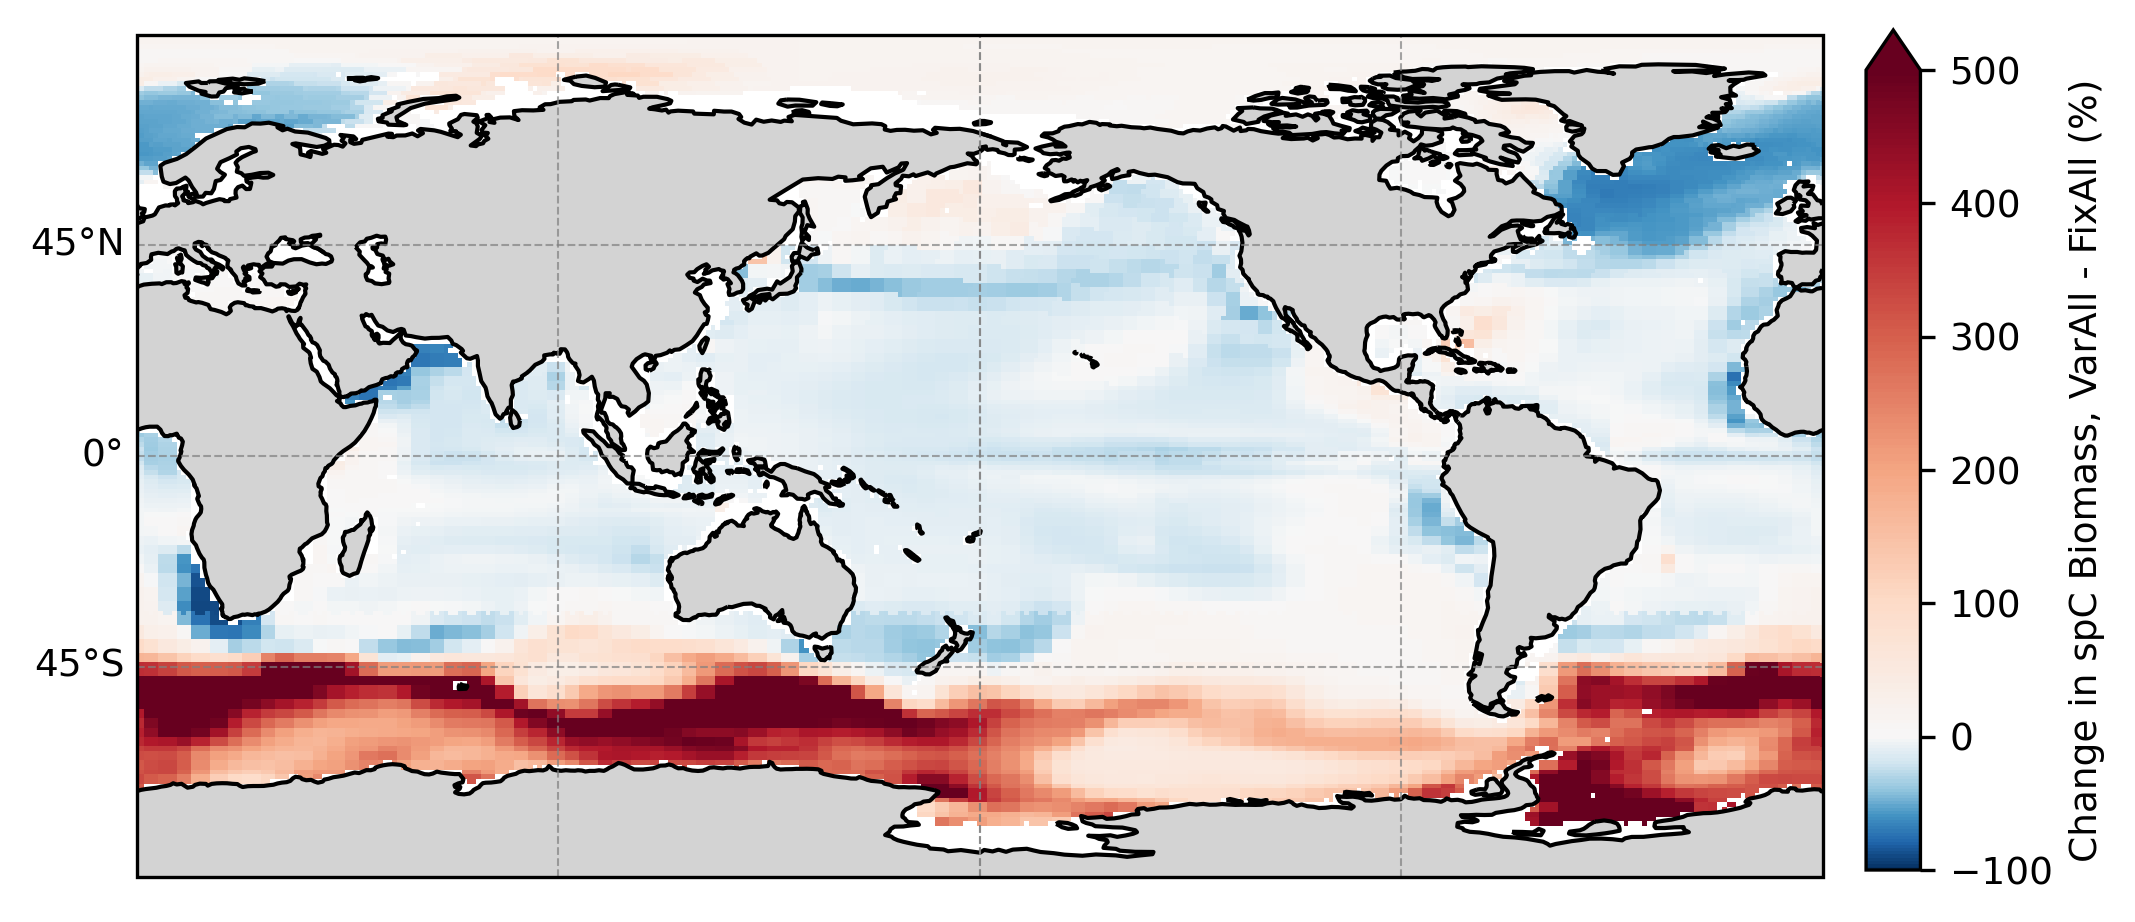

In [11]:
fig = plt.figure(figsize=(7.25, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
ax.set_global()
ax.coastlines(zorder=2)

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])
gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
gl.top_labels = False            # Select top 150 m
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
gl.yformatter = LatitudeFormatter(degree_symbol='°')

norm = TwoSlopeNorm(
    vmin=-100,
    vcenter=0,
    vmax=500
)

mesh = ax.pcolormesh(
    ds_out["lon"], ds_out["lat"], spC_change,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.RdBu.reversed(),
    norm = norm,
    zorder=1
)

# Original colormap
cmap_orig = plt.cm.RdBu_r

# New color positions:
# blue -> white happens at 1/6, then white -> red spans 5/6
colors = cmap_orig(np.linspace(0, 1, 256))

# Build a new lookup table with the midpoint shifted
new_positions = np.concatenate([
    np.linspace(0, 0.5, 43),     # blue to white compressed
    np.linspace(0.5, 1, 213)     # white to red expanded
])

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "RdBu_shifted",
    list(zip(np.linspace(0, 1, 256), cmap_orig(new_positions)))
)

cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])

cbar = ColorbarBase(
    cax,
    cmap=new_cmap,
    norm=mcolors.Normalize(vmin=-100, vmax=500),
    orientation="vertical",
    extend='max'
)

cbar.set_ticks([-100, 0, 100, 200, 300, 400, 500])
cbar.set_label("Change in spC Biomass, VarAll - FixAll (%)")

ax.set_rasterization_zorder(1)
filename = f"figures/spC_change.svg"
plt.savefig(filename, dpi=600, bbox_inches='tight',
        transparent=False)

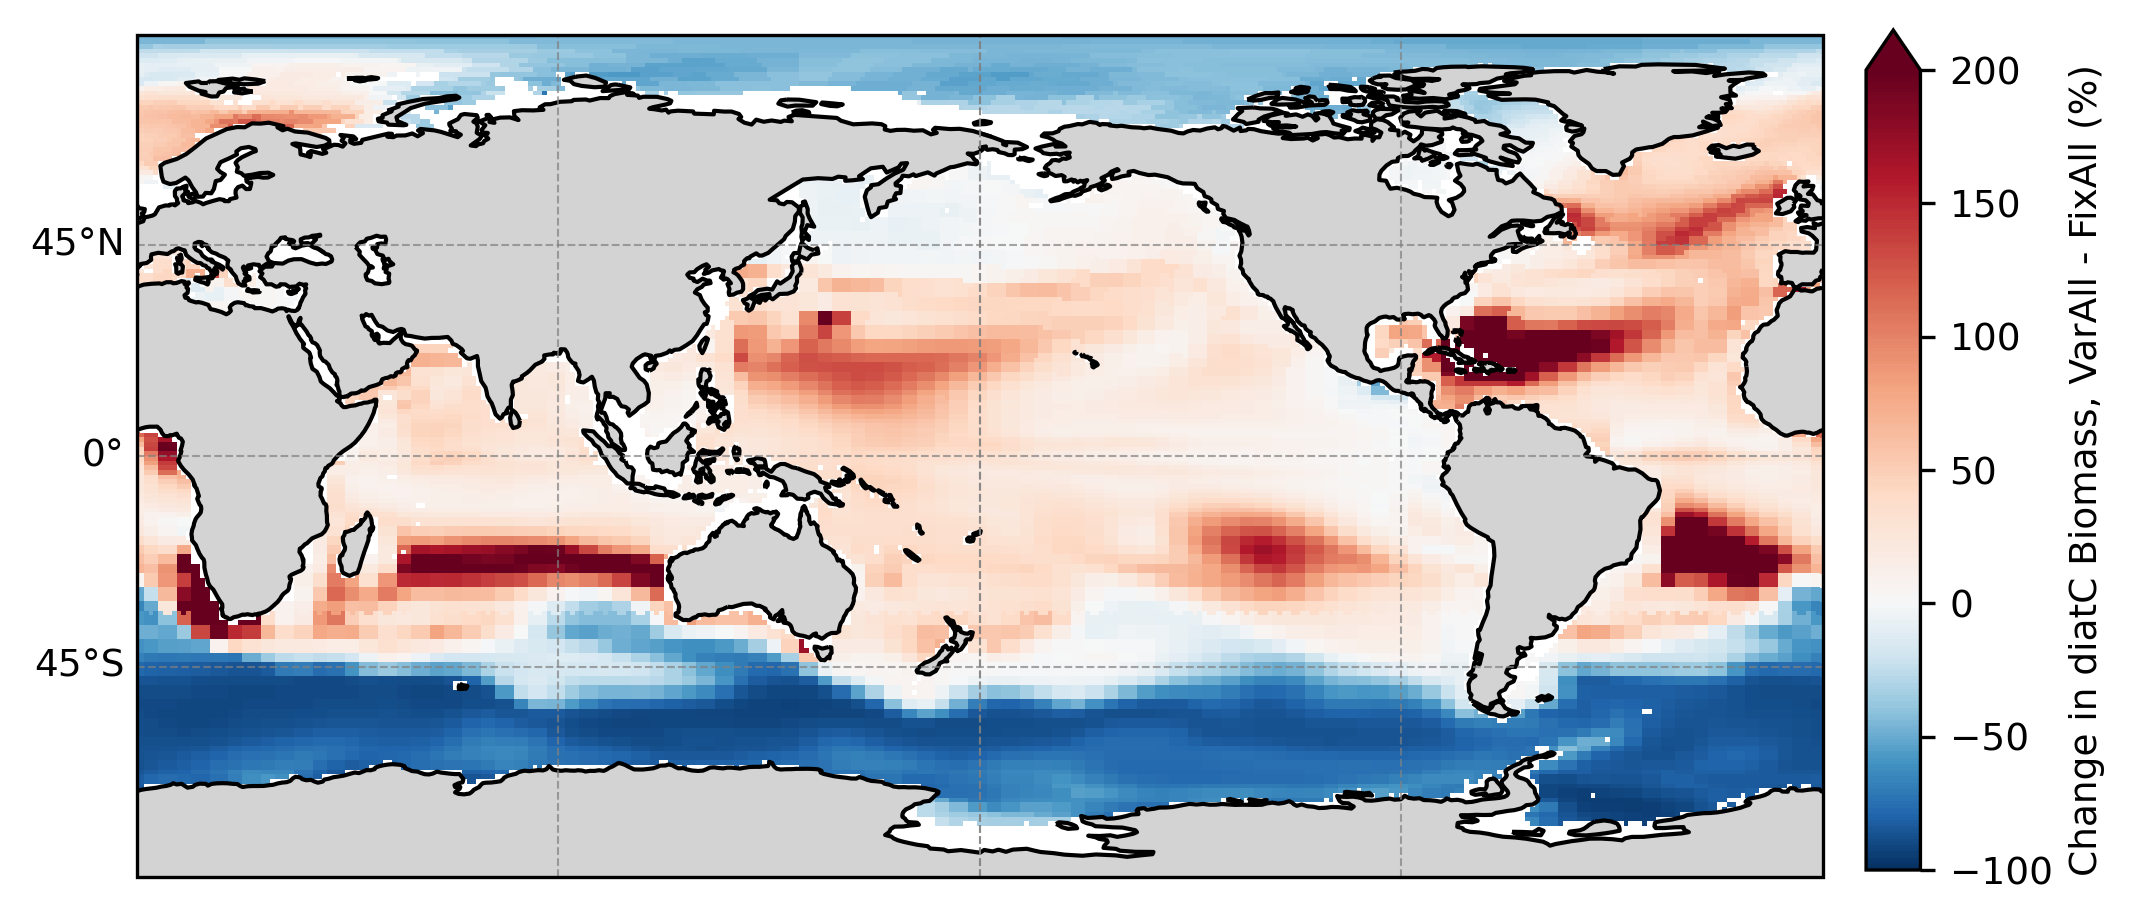

In [10]:
fig = plt.figure(figsize=(7.25, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
ax.set_global()
ax.coastlines(zorder=2)

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])
gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
gl.top_labels = False            # Select top 150 m
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
gl.yformatter = LatitudeFormatter(degree_symbol='°')

norm = TwoSlopeNorm(
    vmin=-100,
    vcenter=0,
    vmax=200
)

mesh = ax.pcolormesh(
    ds_out["lon"], ds_out["lat"], diatC_change,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.RdBu.reversed(),
    norm = norm,
    zorder=1
)

# Original colormap
cmap_orig = plt.cm.RdBu_r

# New color positions:
# blue -> white happens at 1/6, then white -> red spans 5/6
colors = cmap_orig(np.linspace(0, 1, 256))

# Build a new lookup table with the midpoint shifted
new_positions = np.concatenate([
    np.linspace(0, 0.5, 86),     # blue to white compressed
    np.linspace(0.5, 1, 170)     # white to red expanded
])

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "RdBu_shifted",
    list(zip(np.linspace(0, 1, 256), cmap_orig(new_positions)))
)

cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])

cbar = ColorbarBase(
    cax,
    cmap=new_cmap,
    norm=mcolors.Normalize(vmin=-100, vmax=200),
    orientation="vertical",
    extend='max'
)

cbar.set_ticks([-100, -50, 0, 50, 100, 150, 200])
cbar.set_label("Change in diatC Biomass, VarAll - FixAll (%)")

ax.set_rasterization_zorder(1)
filename = f"figures/diatC_change.svg"
plt.savefig(filename, dpi=600, bbox_inches='tight',
        transparent=False)

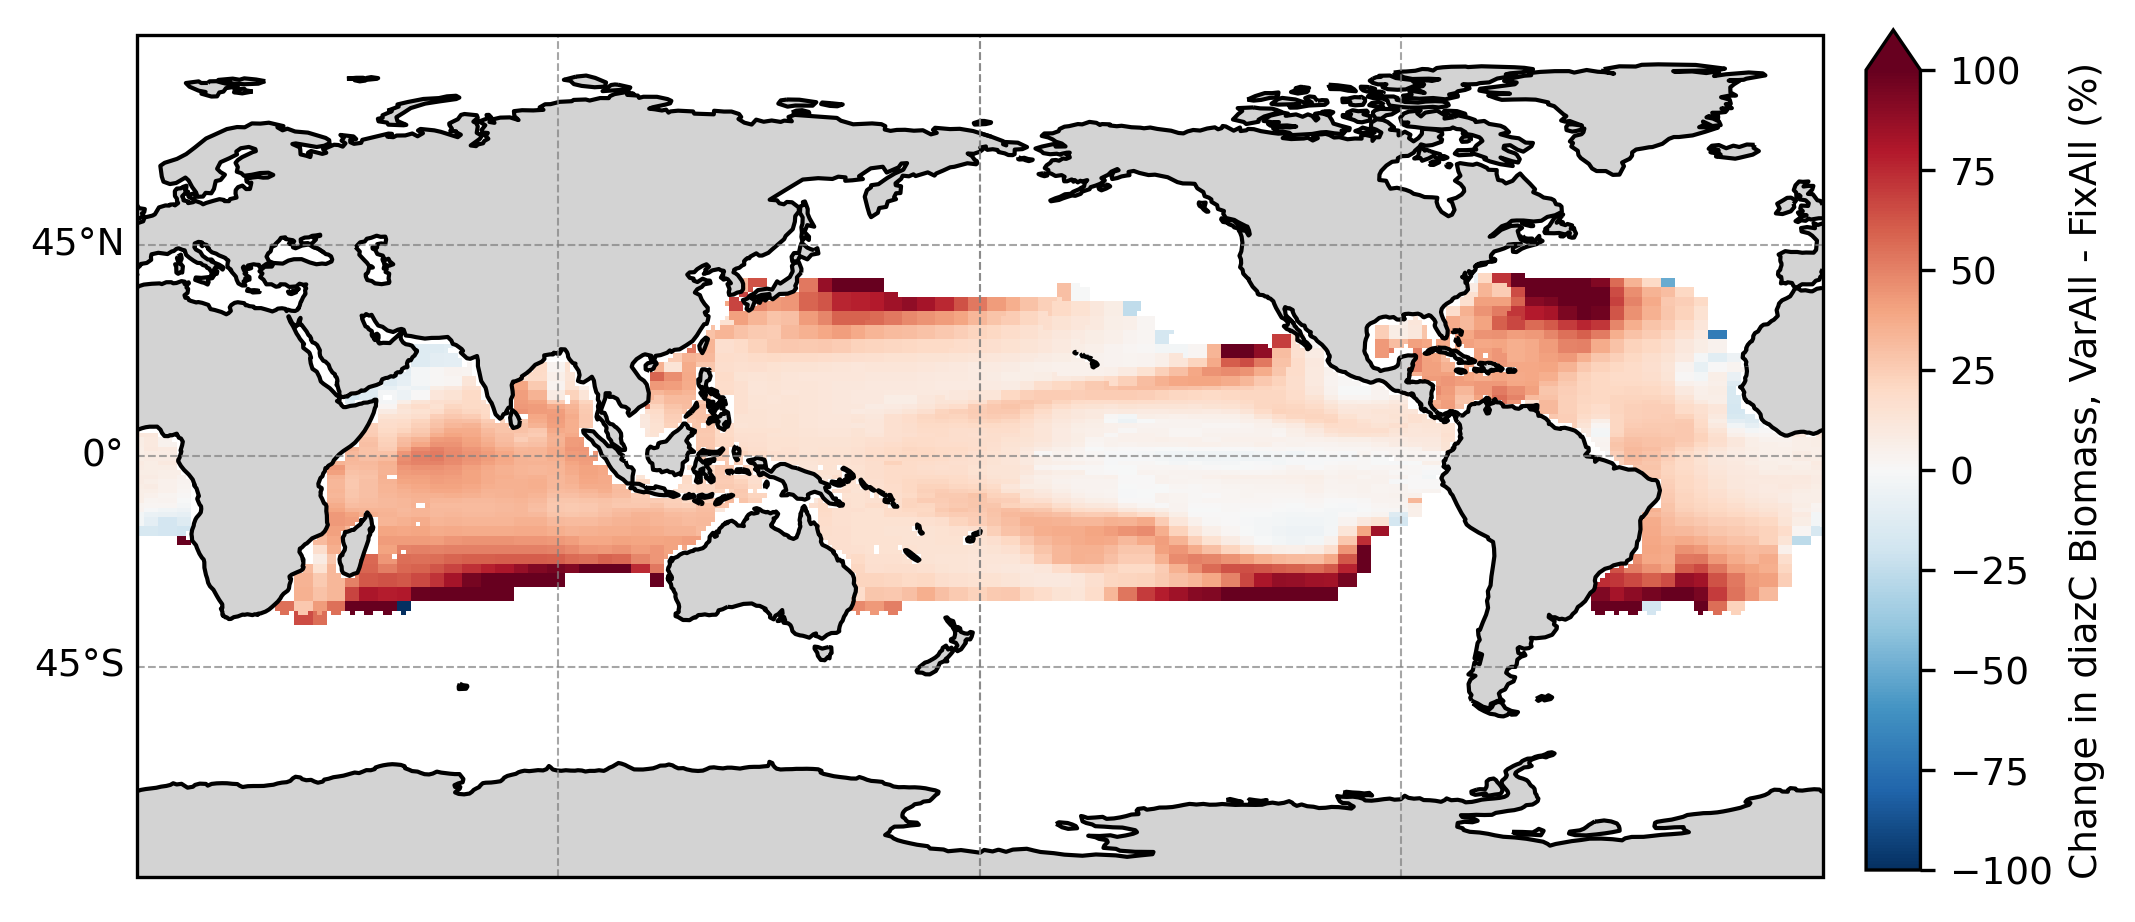

In [15]:
fig = plt.figure(figsize=(7.25, 4), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-180))
ax.add_feature(cart.feature.LAND, facecolor='lightgray', zorder=0)
ax.set_global()
ax.coastlines(zorder=2)

# Gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
gl.xlocator = ticker.FixedLocator([-180, -90, 0, 90, 180])        # Apply original-grid mask if requested
gl.ylocator = ticker.FixedLocator([-90, -45, 0, 45, 90])
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False
gl.left_labels = True
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter(zero_direction_label=False, degree_symbol='°')
gl.yformatter = LatitudeFormatter(degree_symbol='°')

mesh = ax.pcolormesh(
    ds_out["lon"], ds_out["lat"], diazC_change,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap=plt.cm.RdBu.reversed(),
    vmin=-100,
    vmax=100,
    zorder=1
)

cax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = ColorbarBase(
    cax,
    cmap=plt.cm.RdBu.reversed(),
    norm=mcolors.Normalize(vmin=-100, vmax=100),
    orientation="vertical",
    extend='max'
)

cbar.set_ticks([-100, -75, -50, -25, 0, 25, 50, 75, 100])
cbar.set_label("Change in diatC Biomass, VarAll - FixAll (%)")
cbar.set_label("Change in diazC Biomass, VarAll - FixAll (%)")

ax.set_rasterization_zorder(1)
filename = f"figures/diazC_change.svg"
plt.savefig(filename, dpi=600, bbox_inches='tight',
        transparent=False)